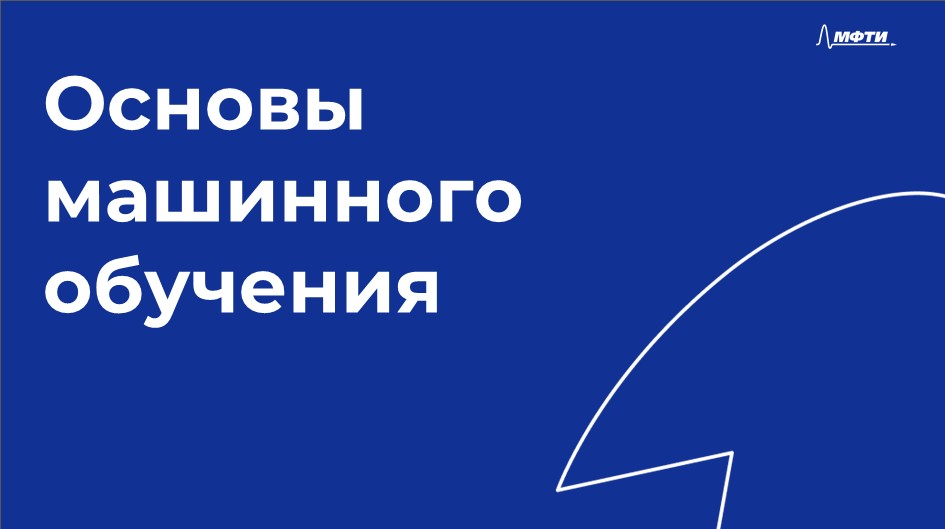

# 🎯 Неделя 1. Семинар 3.

**Сегодня в программе:**

1. Структура временного ряда: тренд и сезонность, декомпозиция.
2. Базовые модели и оценка качества.
3. Статистические модели на основе ARIMA.
4. Фичи для временных рядов (time features, Fourier).

---

Основой сегодняшнего занятия будет `utilsforecast` — удобная продвинутая библиотека для анализа и оценки временных рядов.

Она упрощает визуализацию, расчёт метрик и фичеинжиниринг, позволяя быстро сравнивать модели и сосредоточиться на идеях, а не на инфраструктуре.

In [1]:
! pip install -q statsforecast utilsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.4 MB/s eta 0:00:00


In [3]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ИМПОРТЫ ИЗ STATSFORECAST - главная библиотека для прогнозирования
# Основной класс для обучения моделей и прогнозирования
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,        # Автоматический подбор параметров ARIMA
    HistoricAverage,  # Модель "историческое среднее" - прогноз = среднее за
                      # все время
    Naive,            # Наивная модель - прогноз = последнее значение
    SeasonalNaive,    # Сезонная наивная - прогноз = значение из прошлого сезона
    WindowAverage,    # Скользящее среднее - прогноз = среднее за последние
                      # N дней

)

# ИМПОРТЫ ИЗ UTILSFORECAST - вспомогательные функции
# Функция для оценки качества моделей по разным метрикам
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import (
    fourier,          # Создание рядов Фурье для моделирования сезонности
    pipeline,         # Конвейер для последовательного создания признаков
    time_features,    # Создание календарных признаков
                      # (день недели, месяц и т.д.)
)
# Метрики качества: MAE, MAPE, MSE, RMSE

from utilsforecast.losses import mae, mape, mse, rmse
# Удобная функция для визуализации временных рядов и прогнозов
from utilsforecast.plotting import plot_series

# ИМПОРТ ИЗ STATSMODELS - для декомпозиции временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
from google.colab import files

In [13]:
uploaded = files.upload()


Saving daily_sales_french_bakery.csv to daily_sales_french_bakery.csv


## 🟢 1.Структура временного ряда: тренд и сезонность, декомпозиция

Временной ряд — это последовательность наблюдений, упорядоченных по времени.
В задачах машинного обучения важно понимать, **из каких компонентов он состоит**, прежде чем строить модель:

* **Тренд (Trend)** — долгосрочное направление изменения ряда
  (рост, спад, отсутствие явной динамики).
* **Сезонность (Seasonality)** — регулярно повторяющиеся колебания,
  связанные с календарными циклами (день недели, месяц, год).
* **Шум (Residual / Noise)** — случайные колебания, не объясняемые трендом и сезонностью.

Формально ряд можно записать как:

* аддитивная модель:
  $$y(t) = trend(t) + seasonality(t) + noise(t)$$
* мультипликативная модель:
  $$y(t) = trend(t) \times seasonality(t) \times noise(t)$$

**Сезонная декомпозиция** — это способ явно выделить компоненты временного ряда: тренд, сезонность и остаток (шум).

Однако стоит помнить, что это **инструмент анализа**, а не модель прогнозирования, но без неё сложно осознанно двигаться дальше.


Сегодня мы будем работать с данными о покупках во французской пекарне, познакомимся с ними:

In [14]:
# Загружаем данные, автоматически парсим даты
df = pd.read_csv("daily_sales_french_bakery.csv", parse_dates=["ds"])

# Фильтруем товары с историей >= 28 дней
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)

# Удаляем колонку цены из основного датафрейма
df = df.drop(['unit_price'], axis=1)
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


In [15]:
print(f"Количество уникальных товаров: {df['unique_id'].nunique()}")
print(f"Минимальная дата: {df['ds'].min()}")
print(f"Максимальная дата: {df['ds'].max()}")
print(f"Общее количество записей: {len(df)}")
print(f"Диапазон продаж: от {df['y'].min()} до {df['y'].max()}")
print(f"Средние продажи: {df['y'].mean():.2f}")

Количество уникальных товаров: 121
Минимальная дата: 2021-01-02 00:00:00
Максимальная дата: 2022-09-30 00:00:00
Общее количество записей: 56904
Диапазон продаж: от 0.0 до 919.1
Средние продажи: 9.80


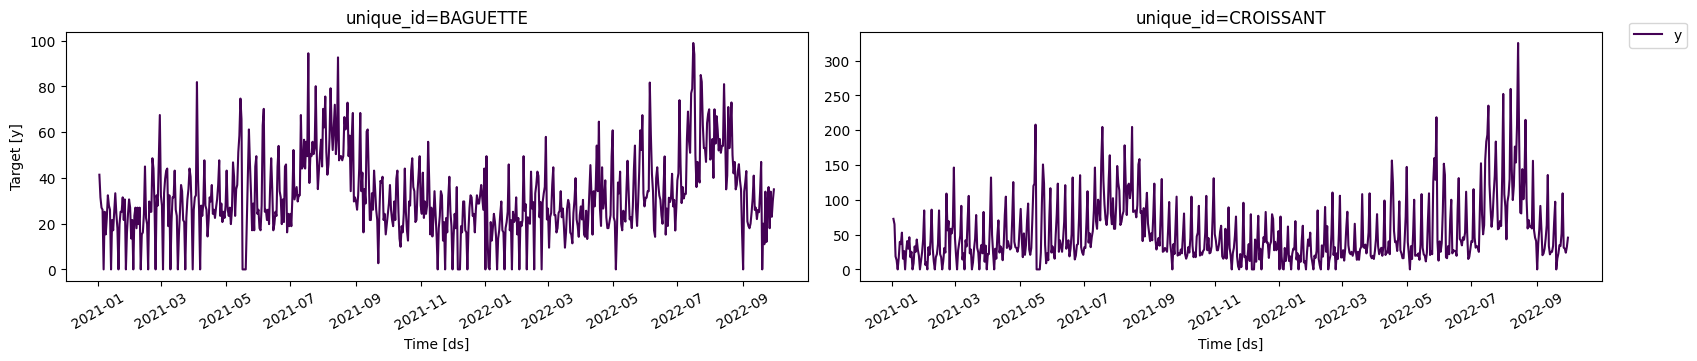

In [16]:
plot_series(df=df, ids=["BAGUETTE", "CROISSANT"], palette="viridis")

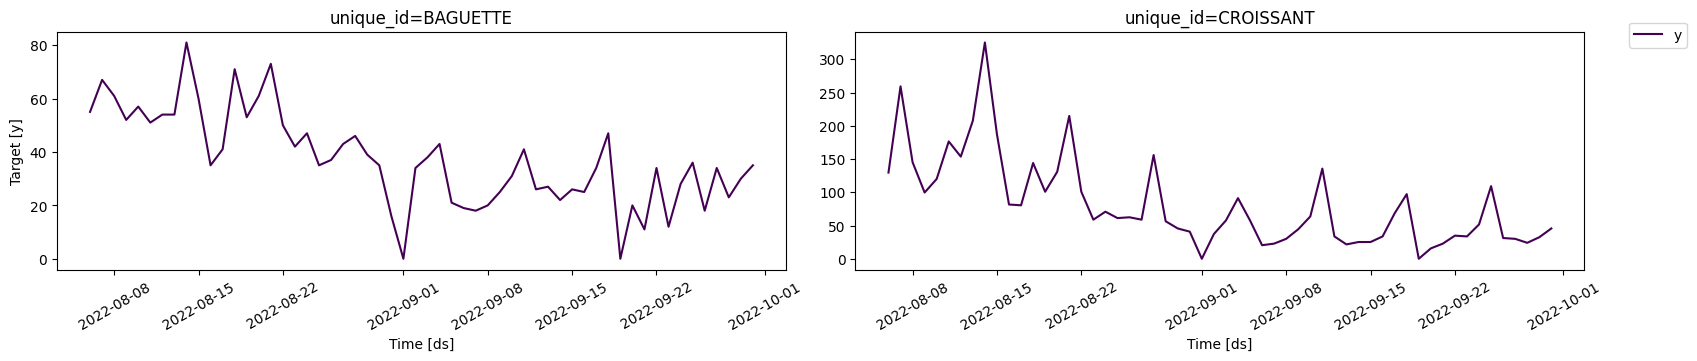

In [17]:
plot_series(df=df, ids=["BAGUETTE", "CROISSANT"], max_insample_length=56, palette="viridis")

Покажем скользящее среднее методами Pandas:

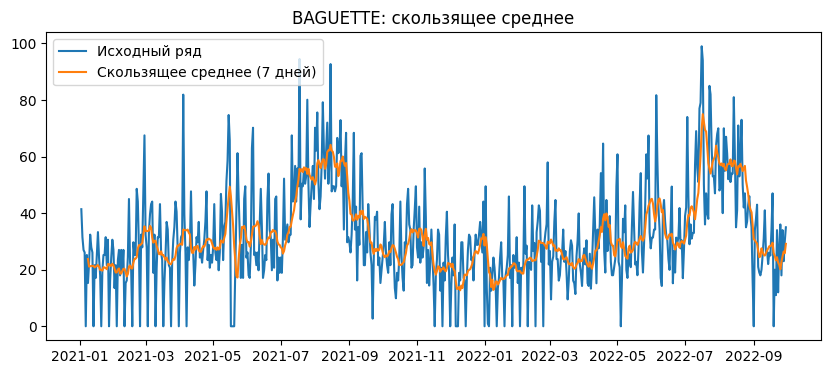

In [18]:
# возьмём один временной ряд для анализа
item_id = "BAGUETTE"

ts = (
    df[df["unique_id"] == item_id]
    .sort_values("ds")
    .set_index("ds")["y"]
)

# 7-дневное скользящее среднее (недельная сезонность)
rolling_mean_7d = ts.rolling(window=7).mean()

plt.figure(figsize=(10, 4))
plt.plot(ts, label="Исходный ряд")
plt.plot(rolling_mean_7d, label="Скользящее среднее (7 дней)")
plt.legend()
plt.title(f"{item_id}: скользящее среднее")
plt.show()

Теперь приступим к сезонной декомпозиции - используем `seasonal_decompose` из `statsmodels`:

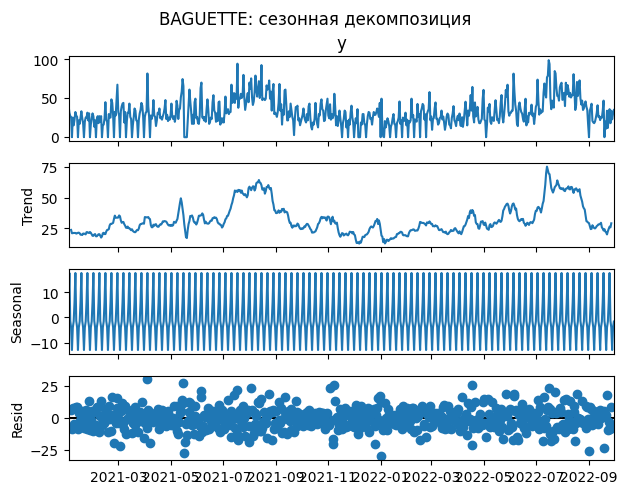

In [19]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7,  # недельная сезонность для дневных данных
)

decomposition.plot()
plt.suptitle(f"{item_id}: сезонная декомпозиция", y=1.02)
plt.show()

## 🟢 2. Базовые модели и оценка качества

Базовые модели (baseline) — это простейшие методы для решения задачи,
которые служат **точкой отсчёта** для оценки более сложных моделей.

Их ключевая роль — показать,
**насколько сложная модель действительно лучше простого правила**.

### Для временных рядов попробуем:

* **Naive**
  Прогноз равен последнему наблюдаемому значению:
  $$
  \hat{y}_{t+h} = y_t
  $$

* **Historic Average**
  Прогноз — среднее всех прошлых наблюдений:
  $$
  \hat{y}*{t+h} = \frac{1}{T} \sum*{i=1}^{T} y_i
  $$

* **Window Average**
  Прогноз — среднее за фиксированное окно последних наблюдений:
  $$
  \hat{y}*{t+h} = \frac{1}{w} \sum*{i=T-w+1}^{T} y_i
  $$

* **Seasonal Naive**
  Прогноз повторяет значение из прошлого сезона:
  $$
  \hat{y}*{t+h} = y*{t+h-s}
  $$
  где $s$ — длина сезона.

### Горизонт прогнозирования

Горизонт прогноза $h$ — это количество шагов вперёд,
на которое строится прогноз.
В данном примере используется недельный горизонт:
$
h = 7
$

In [24]:
# Горизонт прогноза - 7 дней (неделя)
horizon = 7

# Создаем список базовых моделей
models = [
    Naive(),                          # Прогноз = последнее значение
    HistoricAverage(),                 # Прогноз = среднее за всю историю
    WindowAverage(window_size=7),      # Прогноз = среднее за последние 7 дней
    SeasonalNaive(season_length=7)     # Прогноз = значение неделю назад
]

# Создаем объект StatsForecast
# freq="D" означает дневную частоту данных
sf = StatsForecast(models=models, freq="D")

# Обучаем модели на всех данных
sf.fit(df=df)

# Делаем прогноз на 7 дней вперед
preds = sf.predict(h=horizon)

In [25]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


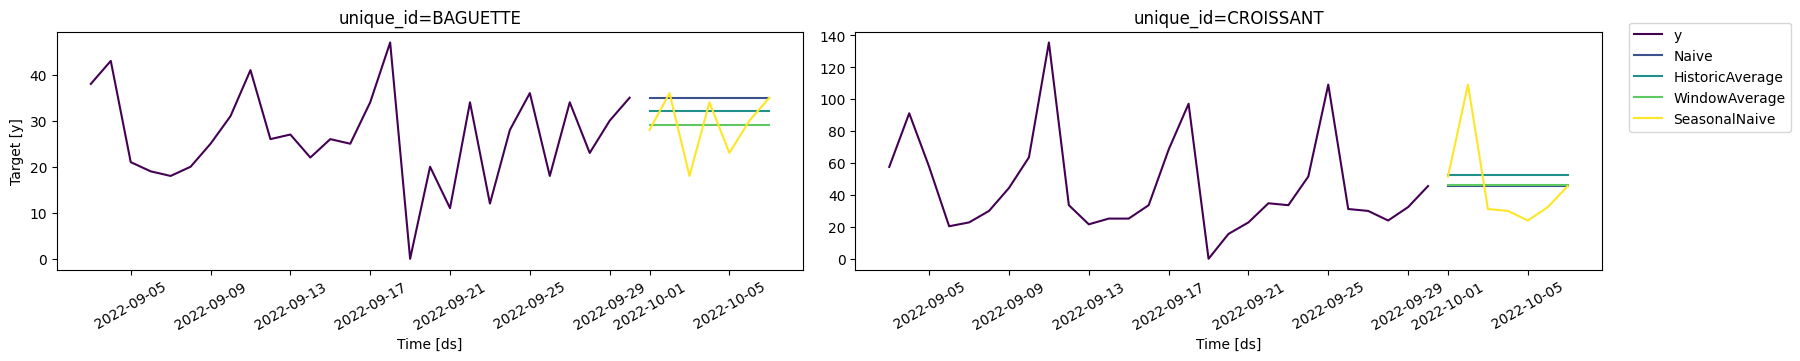

In [26]:
# визуализируем прогноз!
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    palette="viridis"
)

### Оценка качества

Для оценки моделей временных рядов абсолютно аналогично используется **отложенная выборка** (hold-out):

* последние 7 дней — тест,
* все предыдущие наблюдения — обучение.

Качество прогнозов измеряется с помощью уже знакомой нам **MAE (Mean Absolute Error)**:
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
$$

Она удобна для интерпретации, т.к. измеряется в тех же единицах,
что и исходный временной ряд. Но можно использовать и другие метрики регрессии - MSE, RMSE, MAPE, а также некоторые специальные для временных данных.

In [29]:
# Последние 7 дней используем как тестовую выборку
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [30]:
# Обучаем модели на тренировочных данных
sf.fit(df=train)

# Делаем прогноз
preds = sf.predict(h=horizon)

# Делаем прогноз
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [31]:
# Оцениваем качество по метрике MAE (Mean Absolute Error)
# MAE = средняя абсолютная ошибка в единицах продаж
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


Красиво и наглядно визуализируем метрики качества для всех моделей!

In [32]:
# Усредняем метрики по всем товарам для общего сравнения
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


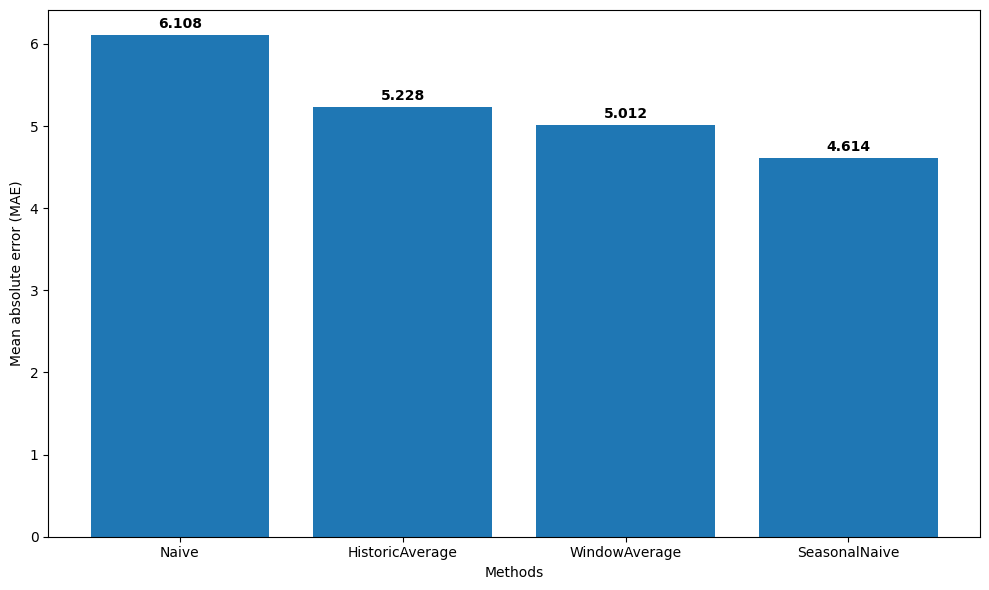

In [33]:
# Подготовка данных для графика
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

## 🟢 3. Статистические модели на основе ARIMA

Цель моделей семейства **ARIMA** — описать временной ряд так,
чтобы по его прошлым значениям можно было предсказывать будущее.

Для этого модель решает три последовательные задачи:

1. сделать временной ряд стационарным,
2. описать зависимость текущего значения от прошлого,
3. учесть систематические ошибки прогноза.

### Шаг 1. Стационарность и дифференцирование

Большинство реальных временных рядов **нестационарны**: среднее значение со временем меняется и присутствует тренд.

Модели ARIMA требуют, чтобы ряд был стационарным - для этого используется **дифференцирование**:
$$
y'*t = y_t - y*{t-1}
$$

Если после одного дифференцирования ряд всё ещё нестационарен,
операцию повторяют. Количество дифференцирований обозначается как $$d$$.

> Дифференцирование отвечает на вопрос:
**"Насколько значение изменилось по сравнению с прошлым шагом?"**

### Шаг 2. Авторегрессия (AR)

После приведения ряда к стационарному виду
мы предполагаем, что текущее значение зависит от нескольких предыдущих:

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t
$$

Это называется **авторегрессией**, её смысл в следующем:
* модель учится, **какие прошлые значения важнее**,
* параметры $\phi_i$ показывают силу этой зависимости.

> Авторегрессия отвечает на вопрос: **"Как прошлые значения влияют на текущее?"**

### Шаг 3. Скользящее среднее (MA)

Даже хорошая модель регулярно ошибается и часть этих ошибок может быть систематической.

Модель **скользящего среднего** учитывает прошлые ошибки:
$$
y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

То есть если модель недавно ошибалась в одну сторону, она корректирует следующий прогноз.

> MA отвечает на вопрос:
**"Как прошлые ошибки помогают улучшить прогноз?"**

### Итого...

Модель **ARIMA** объединяет все три шага:
$$
ARIMA(p, d, q)
$$

* $d$ — делает ряд стационарным,
* $p$ — учитывает влияние прошлых значений,
* $q$ — корректирует прогноз с учётом прошлых ошибок.

А если во временном ряду есть повторяющиеся циклы,
ARIMA расширяется до сезонной версии:
$$
SARIMA(p, d, q)(P, D, Q)_s
$$

Здесь модель отдельно описывает:

* обычную динамику ряда,
* сезонную динамику с периодом $s$.


In [35]:
# Берем только два товара для наглядности
unique_ids = ["BAGUETTE", "CROISSANT"]

# Формируем train и test
small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

In [36]:
# Сравниваем ARIMA (без сезонности) и SARIMA (с сезонностью)
models = [
    AutoARIMA(seasonal=False, alias="ARIMA"), # без сезонной компоненты
    AutoARIMA(season_length=7, alias="SARIMA") # явно моделируем недельную сезонность
]

# Обучение моделей
sf = StatsForecast(models=models, freq="D")
sf.fit(df=small_train) # обучение модели
arima_preds = sf.predict(h=horizon) # предсказание

In [37]:
# Оценка качества по товарам
# Сравниваем качество ARIMA и SARIMA
# Объединяем с тестовыми данными
arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,9.353153,7.449083,17.142857,5.455193,7.877551,12.571429
1,CROISSANT,mae,14.565395,10.359143,17.485714,22.618934,18.244898,12.857143


In [38]:
# Объединенная оценка качества
# Усредняем метрики
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


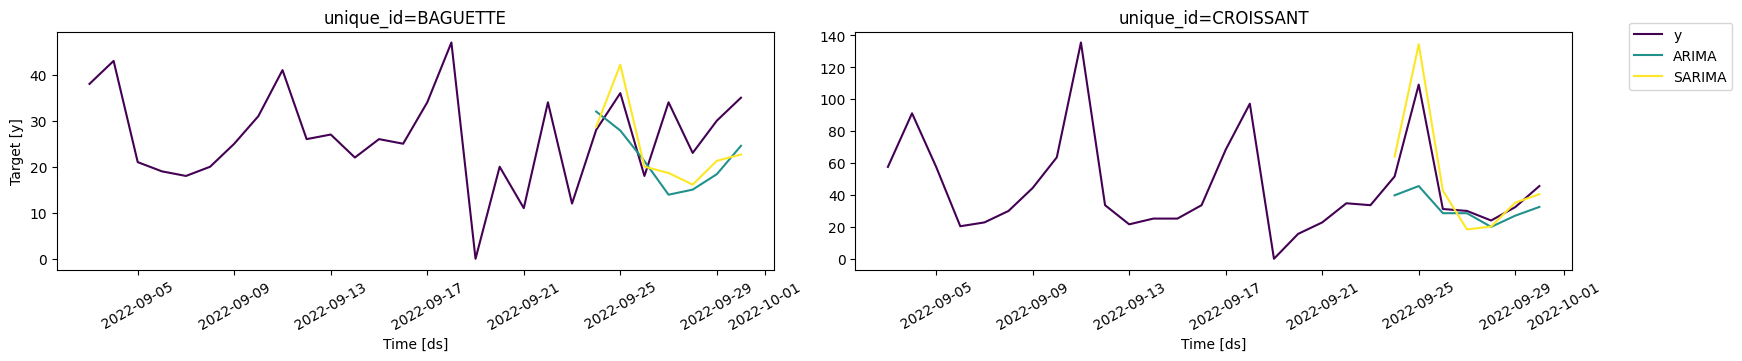

In [39]:
plot_series(
    df=df,
    forecasts_df=arima_preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    palette="viridis")

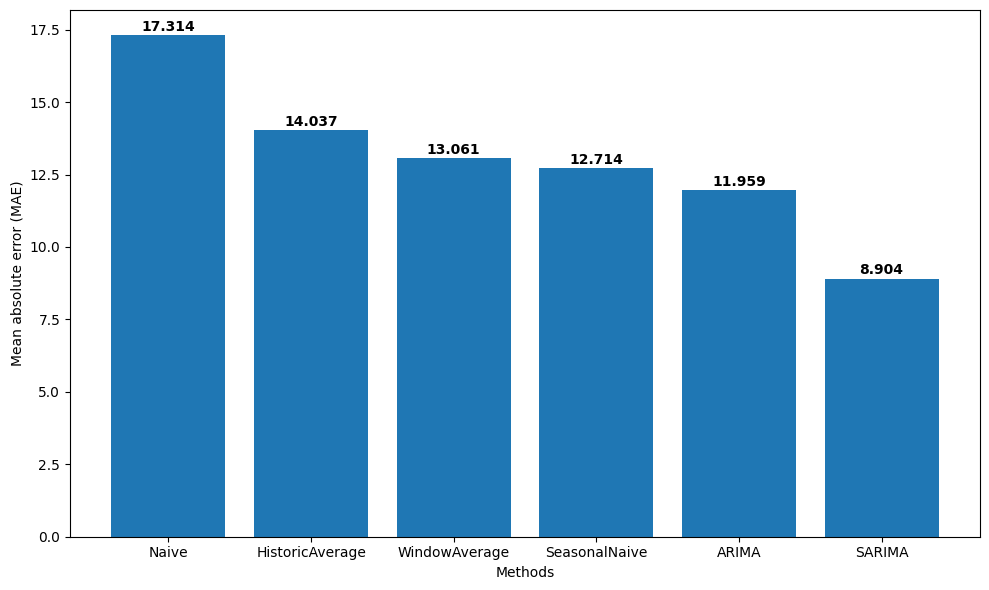

In [40]:
# Еще более наглядно
methods = arima_eval.columns[1:].tolist()
values = arima_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

## 🟢 4. Фичи для временных рядов

До этого момента мы использовали модели,
которые работали **только с самим временным рядом**.

Однако во многих практических задачах значение целевой переменной
зависит не только от прошлого,
но и от **внешних факторов** и **календарного времени**.

**Добавление признаков позволяет модели:**

* учитывать влияние внешних переменных (цены, акции, погода),
* явно кодировать календарные закономерности,
* повысить качество прогноза без усложнения модели.

В ML-подходах работа с фичами — ключевой инструмент,
но и статистические модели могут использовать их через *экзогенные переменные*.

---

**Экзогенные признаки** — это внешние переменные,
которые не являются частью временного ряда,
но влияют на него.

> В примере используется `unit_price` — цена товара.


Таким образом, например, модель SARIMA может быть расширена до вида:
$$
y_t = SARIMA(t) + \beta^\top X_t + \varepsilon_t
$$

где:

* $X_t$ — вектор внешних признаков,
* $\beta$ — их веса.


Помимо внешних переменных,
важную роль играют и **признаки времени**: день недели, номер недели, месяц...

In [41]:
# Используем сохраненные данные с ценой
df = pd.read_csv("daily_sales_french_bakery.csv", parse_dates=["ds"])
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


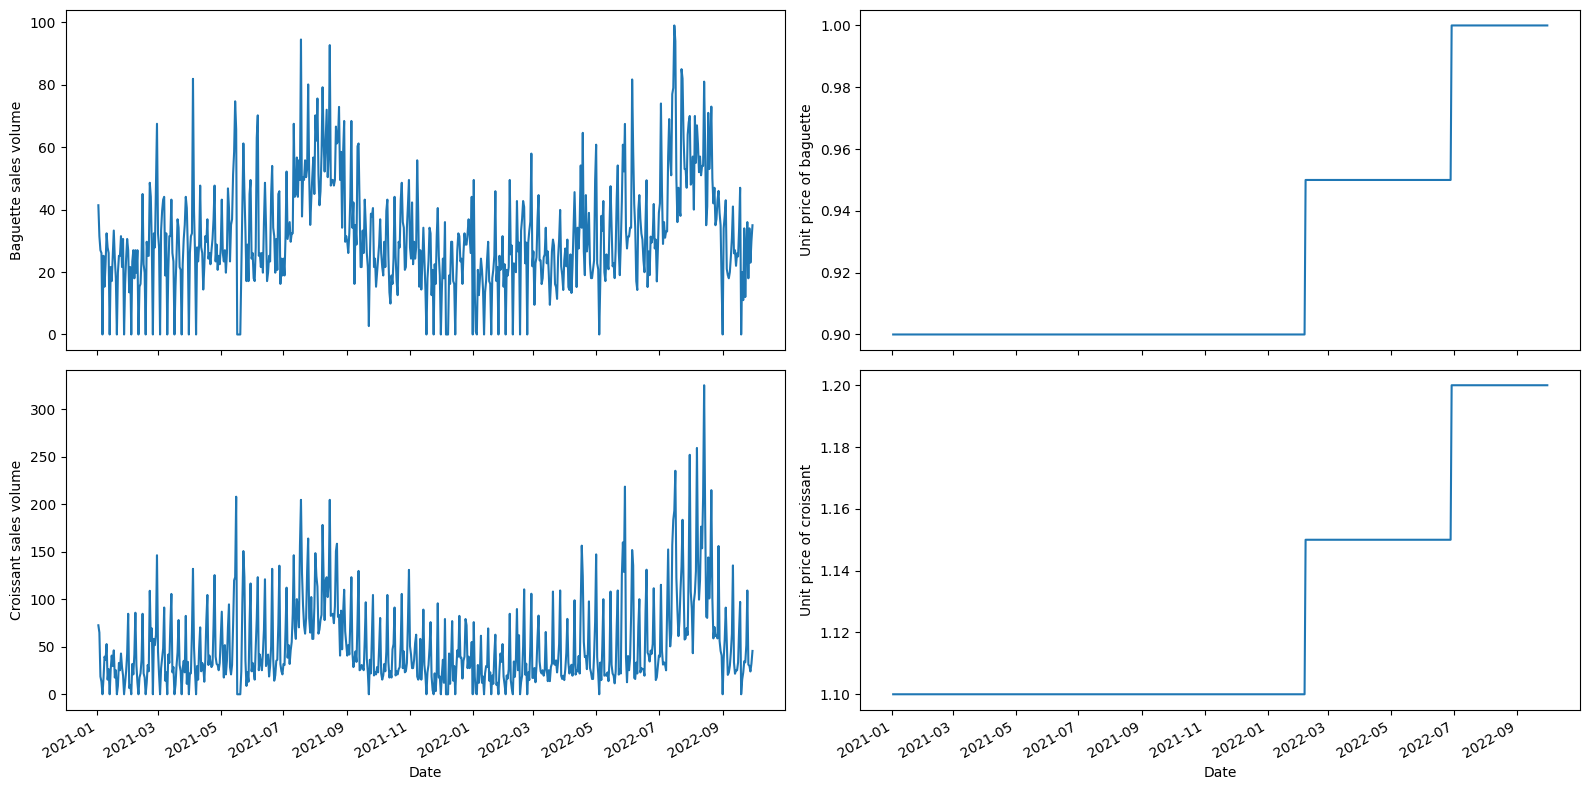

In [42]:
# Анализируем, как цена влияет на объем продаж
baguette_plot_df = df[df["unique_id"] == "BAGUETTE"]
croissant_plot_df = df[df["unique_id"] == "CROISSANT"]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16,8))

ax1.plot(baguette_plot_df["ds"], baguette_plot_df["y"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Baguette sales volume")

ax2.plot(baguette_plot_df["ds"], baguette_plot_df["unit_price"])
ax2.set_xlabel("Date")
ax2.set_ylabel("Unit price of baguette")

ax3.plot(croissant_plot_df["ds"], croissant_plot_df["y"])
ax3.set_xlabel("Date")
ax3.set_ylabel("Croissant sales volume")

ax4.plot(croissant_plot_df["ds"], croissant_plot_df["unit_price"])
ax4.set_xlabel("Date")
ax4.set_ylabel("Unit price of croissant")

fig.autofmt_xdate()
plt.tight_layout()

In [43]:
# Разделяем на train/test
unique_ids = ["BAGUETTE", "CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

In [44]:
# Будущие значения экзогенных переменных (цены на тестовом периоде)
futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0


In [45]:
train

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9
...,...,...,...,...
1255,CROISSANT,2022-09-19,0.0,1.2
1256,CROISSANT,2022-09-20,15.6,1.2
1257,CROISSANT,2022-09-21,22.8,1.2
1258,CROISSANT,2022-09-22,34.8,1.2


In [46]:
# Модель SARIMA с учетом цены
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
arima_exog_preds = sf.predict(h=7, X_df=futr_exog_df)

# Модель SARIMA без цены (для сравнения)
models = [
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train.drop(["unit_price"], axis=1))
arima_preds = sf.predict(h=horizon)

In [47]:
# Объединяем результаты
test_df = (
    test
    .merge(arima_exog_preds, on=["unique_id", "ds"], how="left")
    .merge(arima_preds, on=["unique_id", "ds"], how="left")
)
test_df

,unique_id,ds,y,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,2022-09-24,28.0,1.0,28.898898,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513264,42.182373
2,BAGUETTE,2022-09-26,18.0,1.0,20.423976,20.013652
3,BAGUETTE,2022-09-27,34.0,1.0,19.066264,18.646490
4,BAGUETTE,2022-09-28,23.0,1.0,16.468885,16.114925
5,BAGUETTE,2022-09-29,30.0,1.0,21.656726,21.288019
6,BAGUETTE,2022-09-30,35.0,1.0,23.101235,22.660124
7,CROISSANT,2022-09-24,51.6,1.2,64.424926,64.011002
8,CROISSANT,2022-09-25,109.2,1.2,135.124207,134.488202
9,CROISSANT,2022-09-26,31.2,1.2,43.526109,42.735407


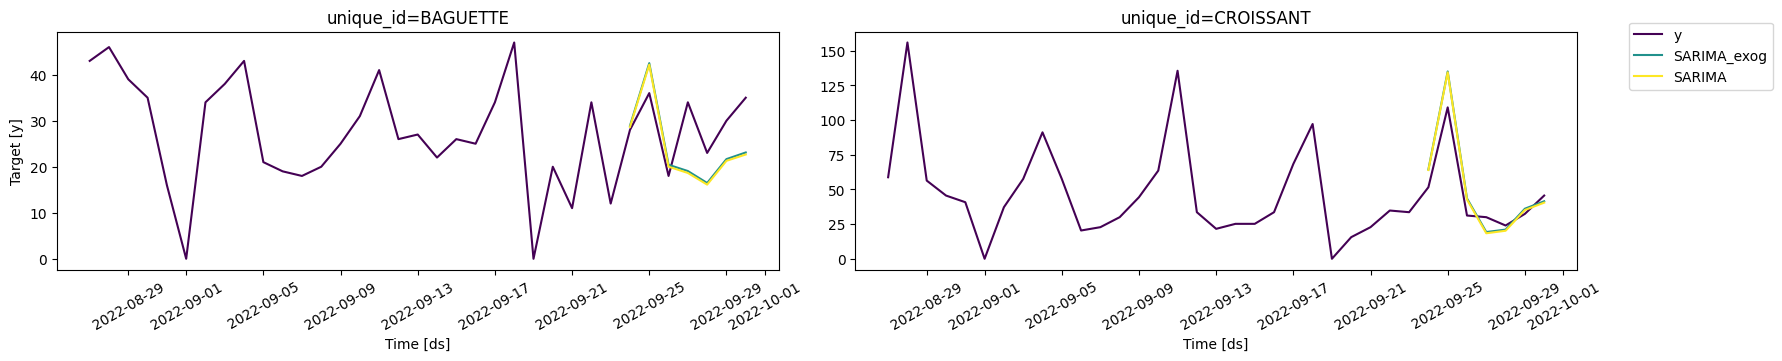

In [48]:
plot_series(
    df=train,
    forecasts_df=test_df,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    models=["SARIMA_exog", "SARIMA"],
    palette="viridis"
)

Теперь соберём **признаки времени**!

In [50]:
# Добавляем календарные признаки и ряды Фурье
# Это помогает модели лучше учитывать сезонность
# Определяем список признаков
# fourier: ряды Фурье для моделирования сезонности (k=2 означает 2 гармоники)
# time_features: календарные признаки (день недели, номер недели, месяц)
features = [
    partial(fourier, season_length=7, k=2),
    partial(time_features, features=["day", "week", "month"])
]

# Создаем признаки для обучающей и тестовой выборок
small_exog_df, futr_exog_df = pipeline(
    df=small_df,
    features=features,
    freq="D",
    h=horizon
)

In [51]:
small_exog_df.head()

,unique_id,ds,y,unit_price,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
84,BAGUETTE,2021-01-02,41.4,0.9,0.781832,0.974928,0.623490,-0.222521,2,53,1
85,BAGUETTE,2021-01-03,31.5,0.9,0.974928,-0.433884,-0.222521,-0.900969,3,53,1
86,BAGUETTE,2021-01-04,27.0,0.9,0.433884,-0.781831,-0.900969,0.623490,4,1,1
87,BAGUETTE,2021-01-05,26.1,0.9,-0.433884,0.781832,-0.900969,0.623490,5,1,1
88,BAGUETTE,2021-01-06,0.0,0.9,-0.974928,0.433884,-0.222521,-0.900969,6,1,1


In [52]:
futr_exog_df

,unique_id,ds,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
0,BAGUETTE,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
1,BAGUETTE,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
2,BAGUETTE,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10
3,BAGUETTE,2022-10-04,-0.433861,0.781800,-0.900980,0.623529,4,40,10
4,BAGUETTE,2022-10-05,-0.974933,0.433846,-0.222500,-0.900987,5,40,10
5,BAGUETTE,2022-10-06,-0.781828,-0.974931,0.623495,-0.222509,6,40,10
6,BAGUETTE,2022-10-07,-0.000009,-0.000017,1.000000,1.000000,7,40,10
7,CROISSANT,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
8,CROISSANT,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
9,CROISSANT,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10


In [54]:
# Оцениваем все модели
eval_df = evaluate(
    test_df,
    metrics=[mae],
)

eval_df = (
    eval_df
    .drop(["unique_id"], axis=1)
    .groupby("metric")
    .mean()
    .reset_index()
)

eval_df

,metric,unit_price,SARIMA_exog,SARIMA
0,mae,36.614286,8.865536,8.904113


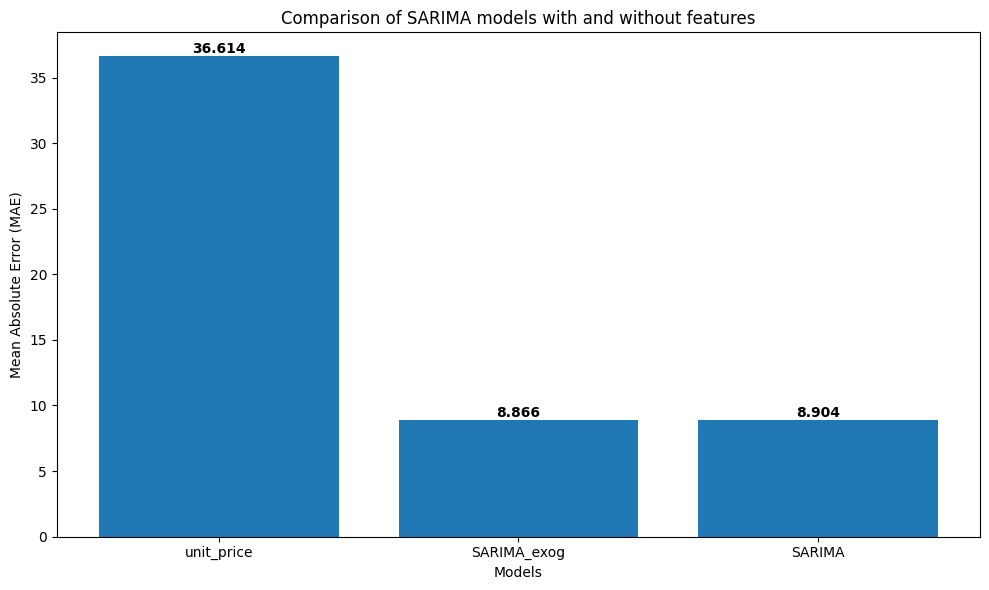

In [55]:
methods = eval_df.columns[1:].tolist()
values = eval_df.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Comparison of SARIMA models with and without features")
plt.tight_layout()
plt.show()